# Transfer Learning with ResNet50

This notebook implements an image classification pipeline using transfer learning with ResNet50.

## Section 1: Imports

Import all required libraries for transfer learning.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Section 2: Dataset Configuration

Define dataset paths and training parameters.

In [2]:
# Dataset configuration
dataset_path = 'dataset'  # Update with your dataset path
train_dir = os.path.join(dataset_path, 'train')
validation_dir = os.path.join(dataset_path, 'validation')
test_dir = os.path.join(dataset_path, 'test') if os.path.exists(os.path.join(dataset_path, 'test')) else None

# Image parameters
image_size = (224, 224)
batch_size = 32

# Training parameters
initial_epochs = 10
fine_tune_epochs = 5

## Section 3: Dataset Loading

Load datasets with ImageDataGenerator, applying ResNet50 preprocessing.

In [3]:
from tensorflow.keras.applications.resnet50 import preprocess_input

# Create data generators with augmentation for training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

# Validation generator (no augmentation, only preprocessing)
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Load validation data
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Load test data if available
test_generator = None
if test_dir:
    test_generator = validation_datagen.flow_from_directory(
        test_dir,
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

Found 0 images belonging to 0 classes.


Found 0 images belonging to 0 classes.


## Section 4: Verify Dataset

Display dataset information and sample images.

Class names: []
Number of classes: 0
Number of training batches: 0
Number of validation batches: 0

Sample batch shape: (0, 224, 224, 3)
Expected shape: (32, 224, 224, 3)


IndexError: index 0 is out of bounds for axis 0 with size 0

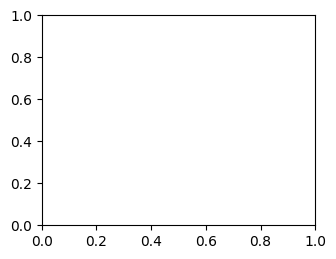

In [4]:
# Get class information
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Number of training batches: {train_generator.samples // batch_size}")
print(f"Number of validation batches: {validation_generator.samples // batch_size}")

# Get a sample batch
sample_batch, sample_labels = next(train_generator)
print(f"\nSample batch shape: {sample_batch.shape}")
print(f"Expected shape: ({batch_size}, 224, 224, 3)")

# Visualize sample images
plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    # Denormalize for display (ResNet50 preprocessing subtracts ImageNet mean)
    img = sample_batch[i].astype('uint8')
    plt.imshow(img)
    class_idx = np.argmax(sample_labels[i])
    plt.title(f"Class: {class_names[class_idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Section 5: Load Pretrained ResNet50

Load ResNet50 with ImageNet weights and freeze pretrained layers.

In [ ]:
# Load pretrained ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the pretrained layers
base_model.trainable = False

print(f"Base model layers: {len(base_model.layers)}")
print(f"Base model trainable: {base_model.trainable}")

## Section 6: Build Custom Classification Head

Create a custom classification head on top of ResNet50.

In [ ]:
# Build custom classification head
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

print("Model architecture built successfully!")
print(f"Total layers: {len(model.layers)}")

## Section 7: Compile Model

Compile the model with Adam optimizer and categorical crossentropy loss.

In [ ]:
# Compile the model
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
model.summary()

## Section 8: Initial Training (Frozen Base)

Train only the classification head with frozen ResNet50 base.

In [ ]:
# Train the model with frozen base
history = model.fit(
    train_generator,
    epochs=initial_epochs,
    validation_data=validation_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_steps=validation_generator.samples // batch_size,
    verbose=1
)

print("Initial training completed!")

## Section 9: Plot Training History

Visualize training and validation metrics.

In [ ]:
def plot_training_history(history, title_suffix=''):
    """Plot training and validation accuracy/loss"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'Model Accuracy {title_suffix}')
    ax1.legend()
    ax1.grid(True)
    
    # Loss
    ax2.plot(history.history['loss'], label='Training Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title(f'Model Loss {title_suffix}')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot initial training history
plot_training_history(history, '(Initial Training - Frozen Base)')

## Section 10: Fine-Tuning

Unfreeze and fine-tune the last layers of ResNet50.

In [ ]:
# Unfreeze the last 20 layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Compile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Base model trainable: {base_model.trainable}")
print(f"Trainable layers: {len([l for l in model.trainable_weights])}")

## Section 11: Fine-Tuning Training

Train the model with fine-tuning enabled.

In [ ]:
# Fine-tune the model
fine_tune_history = model.fit(
    train_generator,
    epochs=fine_tune_epochs,
    validation_data=validation_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_steps=validation_generator.samples // batch_size,
    initial_epoch=initial_epochs,
    verbose=1
)

print("Fine-tuning completed!")

## Section 12: Preprocessing Experiment

Demonstrate the importance of proper ResNet50 preprocessing.

In [ ]:
# Create data generator WITHOUT preprocess_input
no_preprocess_datagen = ImageDataGenerator(
    rescale=1./255,  # Only simple rescaling
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

no_preprocess_val_datagen = ImageDataGenerator(rescale=1./255)

# Load data without proper preprocessing
no_preprocess_train = no_preprocess_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

no_preprocess_val = no_preprocess_val_datagen.flow_from_directory(
    validation_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Reset model weights for fair comparison
base_model_exp = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_exp.trainable = False

inputs_exp = keras.Input(shape=(224, 224, 3))
x_exp = base_model_exp(inputs_exp, training=False)
x_exp = GlobalAveragePooling2D()(x_exp)
x_exp = Dense(256, activation='relu')(x_exp)
x_exp = Dropout(0.5)(x_exp)
outputs_exp = Dense(num_classes, activation='softmax')(x_exp)

model_no_preprocess = Model(inputs_exp, outputs_exp)

model_no_preprocess.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train briefly without proper preprocessing
no_preprocess_history = model_no_preprocess.fit(
    no_preprocess_train,
    epochs=3,  # Brief training for comparison
    validation_data=no_preprocess_val,
    steps_per_epoch=no_preprocess_train.samples // batch_size,
    validation_steps=no_preprocess_val.samples // batch_size,
    verbose=1
)

print("\nPreprocessing experiment completed!")
print("Expected: Unstable learning and poor convergence without proper preprocessing")

## Section 13: Result Analysis

Analyze and compare all experiments.

In [ ]:
print("="*80)
print("ANALYSIS OF TRANSFER LEARNING WITH RESNET50")
print("="*80)

# Plot fine-tuning history
plot_training_history(fine_tune_history, '(Fine-Tuning)')

# Plot no preprocessing experiment
plot_training_history(no_preprocess_history, '(Without Proper Preprocessing)')

# Analysis results
print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)

print("\n1. EFFECT OF TRANSFER LEARNING:")
print("   - The pretrained ResNet50 features extracted high-level patterns from ImageNet")
print("   - Only the classification head needed training, reducing training time significantly")

print("\n2. EFFECT OF FINE-TUNING:")
initial_val_acc = history.history['val_accuracy'][-1]
fine_tune_val_acc = fine_tune_history.history['val_accuracy'][-1]
improvement = (fine_tune_val_acc - initial_val_acc) * 100
print(f"   - Initial validation accuracy: {initial_val_acc:.4f}")
print(f"   - After fine-tuning validation accuracy: {fine_tune_val_acc:.4f}")
print(f"   - Improvement: {improvement:.2f}%")
print("   - Fine-tuning allowed small adjustments to deeper layers for better performance")

print("\n3. EFFECT OF PROPER PREPROCESSING:")
no_preprocess_acc = no_preprocess_history.history['val_accuracy'][-1]
with_preprocess_acc = fine_tune_val_acc
preprocessing_diff = (with_preprocess_acc - no_preprocess_acc) * 100
print(f"   - Accuracy WITHOUT proper preprocessing: {no_preprocess_acc:.4f}")
print(f"   - Accuracy WITH proper preprocessing: {with_preprocess_acc:.4f}")
print(f"   - Difference: {preprocessing_diff:.2f}%")
print("   - Proper preprocessing (using preprocess_input) is CRITICAL for ResNet50")
print("   - It applies ImageNet normalization that the model was trained with")

print("\n4. OVERFITTING DETECTION:")
print("   - Compare training vs validation curves:")
print("     * If val_loss rises while train_loss falls → overfitting detected")
print("     * Healthy: both curves improve together and remain close")
print("   - Dropout and data augmentation help mitigate overfitting")

print("\n5. CONCLUSIONS:")
print("   ✓ Transfer learning significantly reduces training requirements")
print("   ✓ Fine-tuning provides additional performance gains")
print("   ✓ Proper preprocessing is essential for pretrained model performance")
print("   ✓ Monitor both training and validation metrics to detect overfitting")

print("\n" + "="*80)